In [1]:
# Project

# India E-Commerce sales & Customer Analytics Using Python

**An end-to-end exploratory data analysis of 15,000+ online orders placed across 18 Indian states**

---

| | |
|---|---|
| **Domain** | Retail / E-Commerce Analytics |
| **Tools** | Python, NumPy, Pandas, Matplotlib, Seaborn, Plotly |
| **Dataset** | india_ecommerce_sales.csv (synthetic, 15,120 rows x 29 columns) |
| **Period covered** | 01-Jan-2024 to 31-Dec-2025 (24 months) |
| **Currency** | Indian Rupee (INR) |
| **Deliverables** | This notebook, a PDF report, a PowerPoint deck and exported charts |

---

## 1. Business Problem

**BharatKart Retail Pvt. Ltd.** is a mid-sized Indian e-commerce marketplace selling across
eight categories in 25 cities. Over the last two years the company has grown its top line
aggressively through heavy festive discounting and rapid category expansion.

Management is now facing an uncomfortable situation:

 *"Revenue keeps growing, but profit is not growing at the same pace. We do not know which
 categories, which regions and which customers are actually making money for us."*

The leadership team cannot answer basic questions such as which state is most profitable,
how much margin our discounts destroy, or *why our customer ratings are falling in some
regions*. Decisions are being taken on intuition rather than evidence.

This project analyses two full years of transactional data to convert that raw order log
into a clear, quantified picture of where the business makes money, where it loses money,
and what management should do next.

## 2. Dataset Description

The file data/india_ecommerce_sales.csv is a **synthetic but statistically realistic**
order log. Every row is one order line.

### Data dictionary

| Column | Type | Description |
|---|---|---|
| Order_ID | object | Unique identifier of the order |
| Order_Date | date | Date the order was placed |
| Customer_ID | object | Unique identifier of the customer |
| Customer_Name | object | Customer full name |
| Gender | object | Male / Female |
| Age | float | Age of the customer in years |
| Age_Group | object | Age bucket (18-25, 26-35, 36-45, 46-60, 60+) |
| City | object | Delivery city |
| State | object | Delivery state |
| Region | object | North / South / East / West / Central / Northeast |
| Latitude | float | Latitude of the city (for mapping) |
| Longitude | float | Longitude of the city (for mapping) |
| Product_ID | object | Unique identifier of the product |
| Product_Name | object | Product name |
| Category | object | One of 8 merchandising categories |
| Sub_Category | object | Sub-category within the category |
| Quantity | int | Units ordered |
| Unit_Price | float | Listed price per unit before discount (INR) |
| Discount_Percentage | float | Discount applied on the order (%) |
| Sales | float | Net booked revenue after discount (INR) |
| Cost | float | Cost of goods sold (INR) |
| Profit | float | Sales minus Cost, adjusted for returns (INR) |
| Profit_Margin | float | Profit as a percentage of Sales |
| Payment_Method | object | UPI, Credit Card, COD, EMI, ... |
| Order_Status | object | Delivered / Shipped / Returned / Cancelled |
| Delivery_Days | float | Days between order and delivery |
| Customer_Rating | float | Post-delivery rating on a 1-5 scale |
| Customer_Segment | object | Premium / Regular / Budget / Corporate |
| Device_Type | object | Channel used to place the order |

 **Note on synthetic data.** The dataset was produced by scripts/generate_dataset.py
 with a fixed random seed, so every number in this notebook is reproducible. Realistic
 behavioural patterns (festive peaks, discount-driven margin erosion, fashion returns,
 delivery-rating relationship) were built into the generator; the analysis below
 discovers them the same way it would on real data.

## 3. Technologies Used

| Library | Why it is used here |
|---|---|
| **NumPy** | Fast vectorised numeric work, percentiles, conditional flags |
| **Pandas** | Loading, cleaning, grouping, pivoting, time-series resampling |
| **Matplotlib** | Static charts for the report and presentation |
| **Seaborn** | Statistical charts (distributions, box plots, heatmaps) |
| **Plotly Express** | Interactive charts and the India geographic map |
| **Jupyter Notebook** | The analysis environment itself |

In [2]:
import numpy as np                 
import pandas as pd    
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px  
import plotly.graph_objects as go
import json, os, warnings
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

In [3]:
# data Collection

In [4]:
df = pd.read_csv('india_ecommerce_sales.csv')

In [5]:
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23.00,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5.00,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44.00,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3.00,4.50,Corporate,Mobile App
2,ORD109386,2025-05-15,CUST11826,Karan Deshmukh,Female,38.00,36-45,NaN,Gujarat,West,21.17,72.83,P1058,Data Science Handbook,Books,Academic,3,"1,733.50",7.90,"4,791.23","3,946.73",844.50,17.63,UPI,Delivered,2.00,4.80,Regular,Mobile Web
3,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32.00,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3.00,5.00,Premium,Tablet
4,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42.00,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5.00,2.90,Regular,Mobile App
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28.00,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6.00,4.80,Premium,Mobile App
15116,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32.00,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3.00,4.70,Regular,Mobile App
15117,ORD100538,2024-02-08,CUST11722,Priya Rao,F,25.00,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7.00,4.30,Regular,Mobile Web
15118,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40.00,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,EMI,Delivered,3.00,4.40,Budget,Mobile App


In [6]:
df.shape

(15120, 29)

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [8]:
for i in df.columns:
    print(i)

Order_ID
Order_Date
Customer_ID
Customer_Name
Gender
Age
Age_Group
City
State
Region
Latitude
Longitude
Product_ID
Product_Name
Category
Sub_Category
Quantity
Unit_Price
Discount_Percentage
Sales
Cost
Profit
Profit_Margin
Payment_Method
Order_Status
Delivery_Days
Customer_Rating
Customer_Segment
Device_Type


In [9]:
df.dtypes

Order_ID                   str
Order_Date                 str
Customer_ID                str
Customer_Name              str
Gender                     str
Age                    float64
Age_Group                  str
City                       str
State                      str
Region                     str
Latitude               float64
Longitude              float64
Product_ID                 str
Product_Name               str
Category                   str
Sub_Category               str
Quantity                 int64
Unit_Price             float64
Discount_Percentage    float64
Sales                  float64
Cost                   float64
Profit                 float64
Profit_Margin          float64
Payment_Method             str
Order_Status               str
Delivery_Days          float64
Customer_Rating        float64
Customer_Segment           str
Device_Type                str
dtype: object

In [10]:
# Data Cleaning

In [11]:
df.isnull().sum()

Order_ID                 0
Order_Date               0
Customer_ID              0
Customer_Name            0
Gender                 151
Age                    231
Age_Group                0
City                    91
State                    0
Region                   0
Latitude                 0
Longitude                0
Product_ID               0
Product_Name             0
Category                 0
Sub_Category             0
Quantity                 0
Unit_Price               0
Discount_Percentage      0
Sales                    0
Cost                     0
Profit                   0
Profit_Margin            0
Payment_Method         121
Order_Status             0
Delivery_Days          303
Customer_Rating        625
Customer_Segment         0
Device_Type              0
dtype: int64

In [12]:
df.dropna(inplace=True,ignore_index=True)

In [13]:
df.shape

(13649, 29)

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(109)

In [16]:
df.drop_duplicates(inplace = True,ignore_index=True)

In [17]:
df.shape

(13540, 29)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.dtypes

Order_ID                   str
Order_Date                 str
Customer_ID                str
Customer_Name              str
Gender                     str
Age                    float64
Age_Group                  str
City                       str
State                      str
Region                     str
Latitude               float64
Longitude              float64
Product_ID                 str
Product_Name               str
Category                   str
Sub_Category               str
Quantity                 int64
Unit_Price             float64
Discount_Percentage    float64
Sales                  float64
Cost                   float64
Profit                 float64
Profit_Margin          float64
Payment_Method             str
Order_Status               str
Delivery_Days          float64
Customer_Rating        float64
Customer_Segment           str
Device_Type                str
dtype: object

In [20]:
# order_date and age... data types are wrong

In [21]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [22]:
df.dtypes

Order_ID                          str
Order_Date             datetime64[us]
Customer_ID                       str
Customer_Name                     str
Gender                            str
Age                           float64
Age_Group                         str
City                              str
State                             str
Region                            str
Latitude                      float64
Longitude                     float64
Product_ID                        str
Product_Name                      str
Category                          str
Sub_Category                      str
Quantity                        int64
Unit_Price                    float64
Discount_Percentage           float64
Sales                         float64
Cost                          float64
Profit                        float64
Profit_Margin                 float64
Payment_Method                    str
Order_Status                      str
Delivery_Days                 float64
Customer_Rat

In [23]:
df['Age']=df['Age'].astype('int64')

In [24]:
df.dtypes

Order_ID                          str
Order_Date             datetime64[us]
Customer_ID                       str
Customer_Name                     str
Gender                            str
Age                             int64
Age_Group                         str
City                              str
State                             str
Region                            str
Latitude                      float64
Longitude                     float64
Product_ID                        str
Product_Name                      str
Category                          str
Sub_Category                      str
Quantity                        int64
Unit_Price                    float64
Discount_Percentage           float64
Sales                         float64
Cost                          float64
Profit                        float64
Profit_Margin                 float64
Payment_Method                    str
Order_Status                      str
Delivery_Days                 float64
Customer_Rat

In [25]:
df['Delivery_Days']=df['Delivery_Days'].astype('int64')

In [26]:
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5,2.90,Regular,Mobile App
4,ORD109118,2025-05-01,CUST11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash on Delivery,Cancelled,8,3.20,Premium,Desktop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App
13536,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App
13537,ORD100538,2024-02-08,CUST11722,Priya Rao,F,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web
13538,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,EMI,Delivered,3,4.40,Budget,Mobile App


In [27]:
df.describe(include=['int64','float64']).T

,count,mean,std,min,25%,50%,75%,max
Age,"13,540.00",34.29,10.63,1.00,27.00,34.00,41.00,200.00
Latitude,"13,540.00",20.34,6.08,8.52,13.08,19.08,26.45,30.90
Longitude,"13,540.00",77.54,4.08,72.57,73.86,77.10,78.49,91.74
Quantity,"13,540.00",1.95,4.62,-3.00,1.00,1.00,2.00,206.00
Unit_Price,"13,540.00","7,258.64","15,626.47",122.40,782.44,"1,919.74","5,224.56","890,296.75"
Discount_Percentage,"13,540.00",15.27,8.47,0.00,9.10,15.10,21.10,49.20
Sales,"13,540.00","8,148.09","15,366.97",115.39,"1,273.65","2,467.66","6,628.60","204,868.73"
Cost,"13,540.00","7,453.03","15,126.06",105.82,"1,003.49","1,970.96","5,348.60","219,886.83"
Profit,"13,540.00",541.02,"1,759.01","-23,504.19",53.47,336.13,874.27,"23,402.87"
Profit_Margin,"13,540.00",14.26,15.95,-51.78,3.69,14.75,26.11,51.39


**Red flags already visible in .describe()**

| Column | Suspicious value | Why it matters |
|---|---|---|
| Quantity | minimum is **negative** and maximum is in the hundreds | Negative units are impossible; huge quantities are data-entry glitches |
| Age | minimum near **1**, maximum **200** | Not a valid customer age |
| Customer_Rating | maximum above **5** | The rating scale is 1-5 |
| Delivery_Days | maximum near **60** | Almost certainly stuck/lost shipments |
| Unit_Price | maximum far above the highest catalogue price | Price-feed error |

We will handle each of these explicitly in the cleaning section.

In [28]:
df.describe(include=['str']).T

,count,unique,top,freq
Order_ID,13540,13540,ORD101152,1
Customer_ID,13540,3022,CUST12879,32
Customer_Name,13540,1207,Shruti Iyer,62
Gender,13540,6,Male,7292
Age_Group,13540,5,26-35,4496
City,13540,25,Mumbai,1307
State,13540,20,Maharashtra,2709
Region,13540,6,South,4355
Product_ID,13540,67,P1043,349
Product_Name,13540,67,Bru Instant Coffee 200g,349


In [29]:
df['Quantity']>0

0        True
1        True
2        True
3        True
4        True
         ... 
13535    True
13536    True
13537    True
13538    True
13539    True
Name: Quantity, Length: 13540, dtype: bool

In [30]:
df[df['Quantity']<=0]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
4151,ORD101239,2024-03-26,CUST13011,Manish Verma,Female,57,46-60,Jaipur,Rajasthan,North,26.91,75.79,P1046,Maggi Noodles Pack of 12,Grocery,Packaged Food,-3,167.24,12.20,440.55,442.01,-1.46,-0.33,Cash on Delivery,Delivered,4,4.20,Premium,Mobile App
5181,ORD106642,2024-12-09,CUST10361,Rahul Kaur,Male,29,26-35,Chennai,Tamil Nadu,South,13.08,80.27,P1025,Sleepwell Foam Mattress,Home & Furniture,Furniture,-1,"11,160.79",8.30,"10,239.15","7,905.30","2,333.85",22.79,UPI,Delivered,3,4.60,Regular,Mobile App
5276,ORD104712,2024-10-03,CUST13011,Manish Verma,Female,57,46-60,Jaipur,Rajasthan,North,26.91,75.79,P1001,Redmi Note 13 5G,Electronics,Smartphones,-2,"17,497.14",18.70,"14,226.24","14,918.00",-691.76,-4.86,Net Banking,Delivered,3,5.00,Premium,Mobile App
6511,ORD103083,2024-07-15,CUST10894,Suresh Deshmukh,Male,27,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1006,boAt Rockerz 450,Electronics,Headphones,-3,"2,149.37",2.50,"2,094.69","1,485.02",609.67,29.11,Cash on Delivery,Delivered,3,4.80,Regular,Mobile Web
12251,ORD102900,2024-07-06,CUST11252,Vikram Iyer,Female,46,46-60,Bengaluru,karnataka,South,12.97,77.59,P1018,Puma Running Shoes,fashion,Footwear,-1,"4,928.86",15.30,"16,702.54","13,036.50","3,666.04",21.95,UPI,Delivered,4,4.50,Regular,Mobile App


In [31]:
df1=df[~(df['Quantity']<=0)]

In [32]:
df1

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5,2.90,Regular,Mobile App
4,ORD109118,2025-05-01,CUST11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash on Delivery,Cancelled,8,3.20,Premium,Desktop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App
13536,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App
13537,ORD100538,2024-02-08,CUST11722,Priya Rao,F,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web
13538,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,EMI,Delivered,3,4.40,Budget,Mobile App


In [33]:
df1.shape

(13535, 29)

In [34]:
df[df['Age']>100]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
150,ORD102769,2024-06-28,CUST12692,Ishita Joshi,Female,150,36-45,Delhi,Delhi,North,28.70,77.10,P1045,MTR Ready to Eat Combo,Grocery,Packaged Food,1,584.45,0.00,584.45,491.81,92.64,15.85,UPI,Delivered,2,4.90,Premium,Mobile App
1199,ORD113766,2025-11-13,CUST11823,Swapnil Banerjee,Female,150,46-60,Kolkata,West Bengal,East,22.57,88.36,P1013,US Polo Assn Polo T-Shirt,Fashion,Men's Clothing,5,"1,792.40",27.50,"6,496.55","5,054.73","1,441.82",22.19,Credit Card,Delivered,3,4.70,Corporate,Mobile App
6781,ORD109778,2025-06-04,CUST10864,Gaurav Das,Female,150,26-35,Delhi,Delhi,North,28.70,77.10,P1036,Maybelline Fit Me Foundation,Beauty,Makeup,1,"1,103.58",4.40,"1,054.60",593.02,461.58,43.77,UPI,Delivered,5,3.60,Budget,Desktop
8685,ORD102582,2024-06-15,CUST12966,Harsh Chatterjee,Female,200,36-45,Pune,Maharashtra,West,18.52,73.86,P1030,Bombay Dyeing Bedsheet,Home & Furniture,Bedding,2,"1,486.31",11.20,"2,640.25","2,030.69",609.56,23.09,UPI,Delivered,5,4.00,Premium,Tablet
10346,ORD103427,2024-08-04,CUST11521,Ishita Verma,Female,200,36-45,Delhi,Delhi,North,28.70,77.10,P1049,Nivia Football Jersey,Sports,Sportswear,3,"1,535.68",12.10,"4,050.19","2,967.27","1,082.92",26.74,Debit Card,Delivered,4,4.70,Regular,Desktop


In [35]:
df2=df1[~(df1['Age']>100)]

In [36]:
df2

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5,2.90,Regular,Mobile App
4,ORD109118,2025-05-01,CUST11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash on Delivery,Cancelled,8,3.20,Premium,Desktop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App
13536,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App
13537,ORD100538,2024-02-08,CUST11722,Priya Rao,F,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web
13538,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,EMI,Delivered,3,4.40,Budget,Mobile App


In [37]:
df1.shape

(13535, 29)

In [38]:
df2.shape

(13530, 29)

In [39]:
df3=df2[(df2['Customer_Rating']>=1) & (df2['Customer_Rating']<=5)]

In [40]:
df3

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5,2.90,Regular,Mobile App
4,ORD109118,2025-05-01,CUST11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash on Delivery,Cancelled,8,3.20,Premium,Desktop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App
13536,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi's Slim Fit Jeans,Fashion,Men's Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App
13537,ORD100538,2024-02-08,CUST11722,Priya Rao,F,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web
13538,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,EMI,Delivered,3,4.40,Budget,Mobile App


In [41]:
df3.shape

(13524, 29)

In [42]:
df3[df3['Unit_Price']>800000]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
6209,ORD101985,2024-05-10,CUST12967,Ananya Singh,Female,49,46-60,Chennai,Tamil Nadu,South,13.08,80.27,P1004,HP Pavilion 15,Electronics,Laptops,1,"890,296.75",15.40,"56,171.60","55,236.50",935.10,1.66,EMI,Delivered,4,4.80,Regular,Mobile App


In [43]:
df3.loc[6209,'Unit_Price']=56171.60

In [44]:
df3[df3['Unit_Price']>800000]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type


In [45]:
# Object >> test

In [46]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [47]:
# remove extra space and convert to title case

In [216]:
def lower_strip(df):
    for i in df.columns:
        if pd.api.types.is_string_dtype(df[i]):     # correct string-column test
            df[i] = df[i].str.strip().str.title()
    return df

df3 = lower_strip(df3)
df3.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,Ord101152,2024-03-21,Cust13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1Kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,Upi,Delivered,5,4.20,Premium,Mobile App
1,Ord107594,2025-01-31,Cust12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window Ac,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,Ord102186,2024-05-21,Cust12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,Ord113618,2025-11-08,Cust12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women'S Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash On Delivery,Returned,5,2.90,Regular,Mobile App
4,Ord109118,2025-05-01,Cust11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10Kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash On Delivery,Cancelled,8,3.20,Premium,Desktop


In [133]:
lower_strip(df3)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,Ord101152,2024-03-21,Cust13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1Kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,Upi,Delivered,5,4.20,Premium,Mobile App
1,Ord107594,2025-01-31,Cust12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window Ac,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App
2,Ord102186,2024-05-21,Cust12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet
3,Ord113618,2025-11-08,Cust12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women'S Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash On Delivery,Returned,5,2.90,Regular,Mobile App
4,Ord109118,2025-05-01,Cust11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10Kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash On Delivery,Cancelled,8,3.20,Premium,Desktop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,Ord105700,2024-11-02,Cust13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App
13536,Ord110743,2025-07-24,Cust12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App
13537,Ord100538,2024-02-08,Cust11722,Priya Rao,Female,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web
13538,Ord109413,2025-05-16,Cust13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,Emi,Delivered,3,4.40,Budget,Mobile App


In [134]:
df3.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [135]:
def get_unique(df):
    for i in df.columns:
        if df[i].dtype=='str':
            print(i,'Unique>>',df[i].unique())

In [136]:
get_unique(df3)

Order_ID Unique>> <StringArray>
['Ord101152', 'Ord107594', 'Ord102186', 'Ord113618', 'Ord109118', 'Ord104054', 'Ord101842', 'Ord109287', 'Ord106139', 'Ord101749',
 ...
 'Ord107567', 'Ord111450', 'Ord101373', 'Ord113928', 'Ord100920', 'Ord105700', 'Ord110743', 'Ord100538', 'Ord109413', 'Ord112464']
Length: 13524, dtype: str
Customer_ID Unique>> <StringArray>
['Cust13416', 'Cust12988', 'Cust12825', 'Cust12560', 'Cust11485', 'Cust12272', 'Cust11168', 'Cust12020', 'Cust10513', 'Cust11617',
 ...
 'Cust11854', 'Cust10107', 'Cust13496', 'Cust10682', 'Cust13519', 'Cust13497', 'Cust12836', 'Cust12956', 'Cust13558', 'Cust11726']
Length: 3021, dtype: str
Customer_Name Unique>> <StringArray>
[         'Tanvi Rao', 'Swapnil Chatterjee',       'Swapnil Bhat',       'Imran Sharma',      'Deepak Mishra',         'Harsh Bose',  'Shruti Chatterjee',
         'Yash Joshi',       'Farhan Patil',      'Rajesh Sharma',
 ...
         'Rahul Gill',      'Tejas Chauhan',  'Siddharth Chauhan',        'Karan Men

In [137]:
get_unique(df3[['Gender','City', 'State', 'Region', 'Category', 'Sub_Category',
                'Payment_Method', 'Order_Status','Customer_Segment', 'Device_Type']])

Gender Unique>> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
City Unique>> <StringArray>
[             'Kochi',           'Gurugram',             'Mumbai',             'Kanpur',           'Guwahati',        'Bhubaneswar',           'Ludhiana',
            'Chennai',          'Hyderabad',          'Bengaluru',              'Delhi',          'Ahmedabad',              'Surat',               'Pune',
            'Kolkata',             'Jaipur',             'Indore',             'Nagpur', 'Thiruvananthapuram',             'Mysuru',         'Coimbatore',
         'Chandigarh',             'Bhopal',              'Patna',            'Lucknow']
Length: 25, dtype: str
State Unique>> <StringArray>
[        'Kerala',        'Haryana',    'Maharashtra',  'Uttar Pradesh',          'Assam',         'Odisha',         'Punjab',     'Tamil Nadu',
      'Telangana',      'Karnataka',          'Delhi',        'Gujarat',    'West Bengal',      'Rajasthan', 'Madhya Pradesh',     'Chandigarh',
     

In [138]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'Year'],
      dtype='str')

In [139]:
# Gender and payment method

In [140]:
get_unique(df3[['Gender']])

Gender Unique>> <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [141]:
df3=df3.replace({'Gender':{'F':'Female','M':'Male'}})

In [142]:
get_unique(df3[['Gender']])

Gender Unique>> <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [143]:
get_unique(df3[['Payment_Method']])

Payment_Method Unique>> <StringArray>
['Upi', 'Credit Card', 'Wallet', 'Cash On Delivery', 'Emi', 'Debit Card', 'Net Banking']
Length: 7, dtype: str


In [144]:
df3=df3.replace({'Payment_Method':{"Cod":"Cash On Delivery"}})

In [145]:
get_unique(df3[['Payment_Method']])

Payment_Method Unique>> <StringArray>
['Upi', 'Credit Card', 'Wallet', 'Cash On Delivery', 'Emi', 'Debit Card', 'Net Banking']
Length: 7, dtype: str


In [146]:
df3.to_csv('Clean_sales_ecommerce.csv')

In [147]:
df3.shape

(13524, 29)

In [148]:
# EDA (Exploratort Data Analysis)

In [149]:
df=df3.copy()

In [150]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [151]:
# 1) # Q .Total order placed ,Total Sales ,Total profit,Total cost 

In [152]:
df['Order_ID'].count()

np.int64(13524)

In [153]:
# total order placed > 13524

In [154]:
df['Sales'].sum()

np.float64(110254998.16)

In [155]:
# total sales >> 110254998.16 >> 11Cr

In [156]:
df['Profit'].sum()

np.float64(7312868.93)

In [157]:
# total profit >> 7312868.93 >> 73 Lakhs

In [158]:
df['Cost'].sum()

np.float64(100856685.52)

In [159]:
# total Cost >> 100856685.52 >> 10 Cr

In [160]:
# Q2. category wise total sales

In [161]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [162]:
df.groupby('Category')['Sales'].sum()

Category
Appliances         19,847,848.49
Beauty              2,751,531.28
Books               1,233,452.30
Electronics        54,861,340.39
Fashion            13,415,042.62
Grocery             3,779,510.51
Home & Furniture    9,155,833.57
Sports              5,210,439.00
Name: Sales, dtype: float64

In [163]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [164]:
top_cat=df.pivot_table(values='Sales',index='Category',aggfunc='sum').sort_values(by='Sales',ascending=False)

In [165]:
top_cat

,Sales
Category,
Electronics,"54,861,340.39"
Appliances,"19,847,848.49"
Fashion,"13,415,042.62"
Home & Furniture,"9,155,833.57"
Sports,"5,210,439.00"
Grocery,"3,779,510.51"
Beauty,"2,751,531.28"
Books,"1,233,452.30"


In [166]:
top_cat.index

Index(['Electronics', 'Appliances', 'Fashion', 'Home & Furniture', 'Sports', 'Grocery', 'Beauty', 'Books'], dtype='str', name='Category')

In [167]:
top_cat['Sales']

Category
Electronics        54,861,340.39
Appliances         19,847,848.49
Fashion            13,415,042.62
Home & Furniture    9,155,833.57
Sports              5,210,439.00
Grocery             3,779,510.51
Beauty              2,751,531.28
Books               1,233,452.30
Name: Sales, dtype: float64

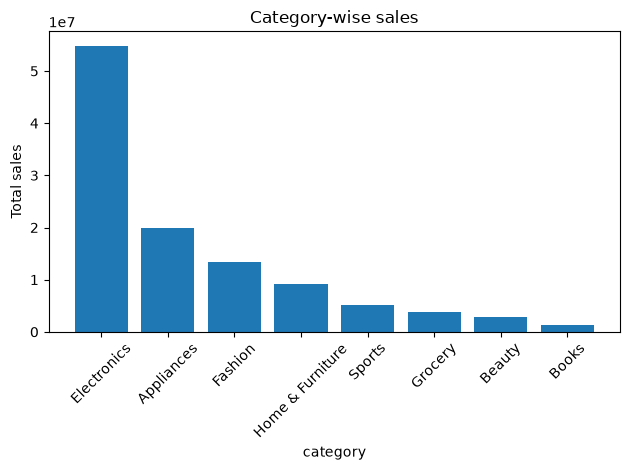

In [168]:
plt.bar(x=top_cat.index,height=top_cat['Sales'])
plt.title('Category-wise sales')
plt.xlabel('category')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

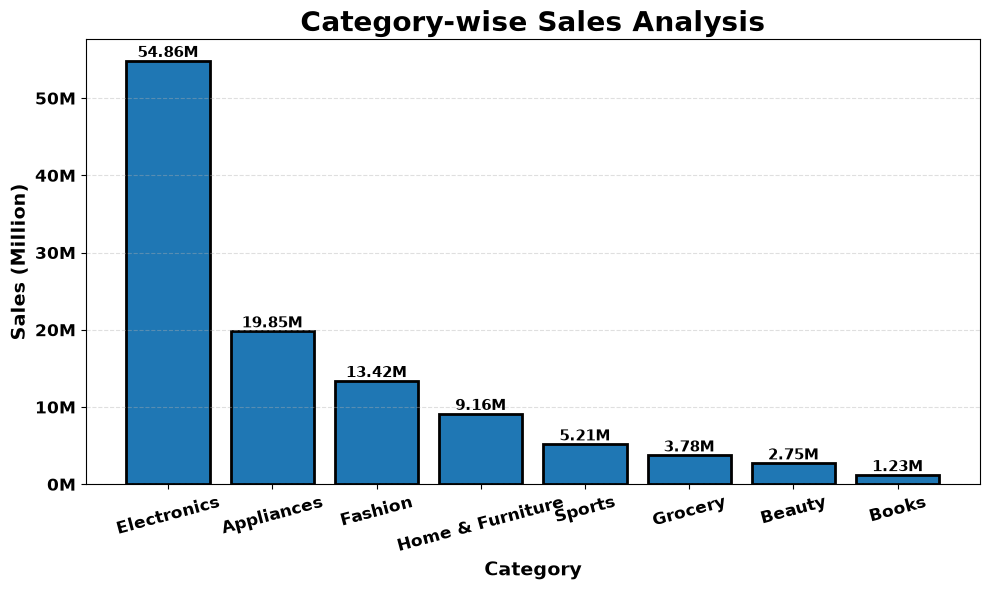

In [169]:
import matplotlib.ticker as ticker

# Category-wise Sales
cat_sales = df.pivot_table(values='Sales',
                           index='Category',
                           aggfunc='sum').sort_values(by='Sales', ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(cat_sales.index,
               cat_sales['Sales'],
               edgecolor='black',
               linewidth=2)

# Title and Labels (Bold)
plt.title("Category-wise Sales Analysis",
          fontsize=20, fontweight='bold')

plt.xlabel("Category",
           fontsize=14, fontweight='bold')

plt.ylabel("Sales (Million)",
           fontsize=14, fontweight='bold')

# Y-axis in Millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Bold X & Y ticks
plt.xticks(fontsize=12, fontweight='bold', rotation=15)
plt.yticks(fontsize=12, fontweight='bold')

# Value labels on bars (Millions)
for bar in bars:
    value = bar.get_height()/1e6
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{value:.2f}M",
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Electronics is the highest-selling category with 54.86 Million in sales.
Appliances ranks second with 19.77 Million in sales.
Fashion generated 13.41 Million in sales.
Home & Furniture recorded the lowest sales among the displayed categories at 9.16 Million.
The chart clearly shows that Electronics contributes the largest share of overall sales, indicating it is the company's strongest-performing category.

In [170]:
# Region-wise Analysis

In [171]:
region_sales=df.pivot_table(values='Sales',index='Region',aggfunc='sum').sort_values(by='Sales',ascending=False)

In [172]:
region_sales

,Sales
Region,
South,"35,931,875.11"
West,"33,995,489.68"
North,"27,598,955.72"
East,"7,597,311.75"
Central,"3,751,865.69"
Northeast,"1,379,500.21"


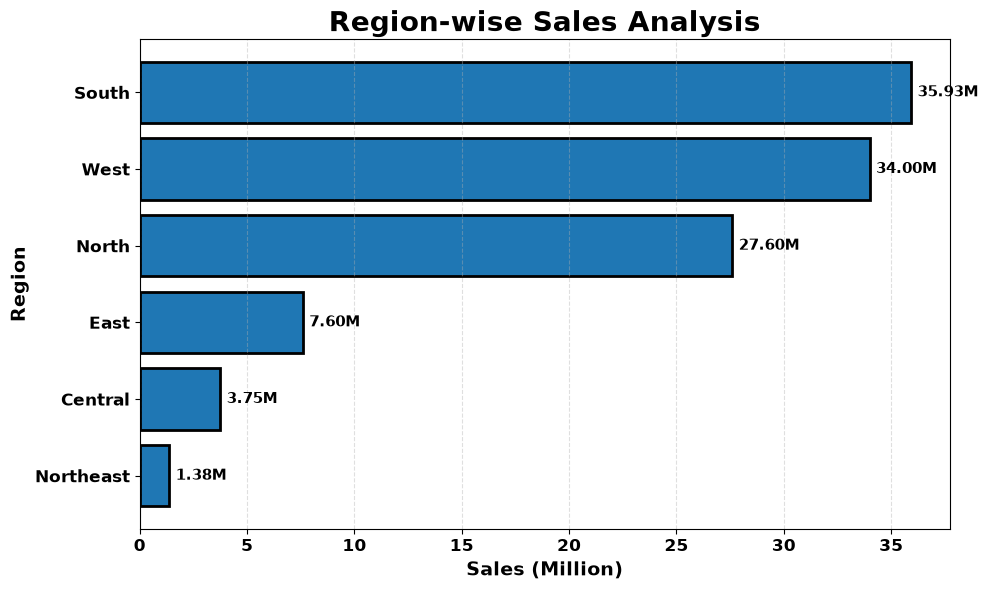

In [173]:
# Sort ascending for horizontal bar chart
plot_data = region_sales.sort_values(by='Sales', ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data.index,
    plot_data['Sales'] / 1e6,
    edgecolor='black',
    linewidth=2
)

# Title and labels
plt.title(
    'Region-wise Sales Analysis',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel(
    'Sales (Million)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    'Region',
    fontsize=14,
    fontweight='bold'
)

# Bold tick labels
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Add values at end of bars
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}M',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

South is the highest-performing region with 35.93M in sales, followed closely by West with 33.99M. North also performs strongly with 27.52M. However, sales drop significantly in East (7.60M), Central (3.75M), and Northeast (1.38M).
The major insight is that sales are heavily concentrated in South, West, and North, while Northeast is the weakest-performing region. The business should investigate the reasons behind strong performance in the top three regions and consider targeted marketing campaigns, product availability, promotions, and customer acquisition strategies to improve sales in East, Central, and especially Northeast.

In [174]:
# Q4. which categories do customers buy most often?

In [175]:
df['Category'].value_counts()

Category
Fashion             3247
Grocery             2594
Beauty              1937
Electronics         1864
Home & Furniture    1501
Appliances           813
Books                806
Sports               762
Name: count, dtype: int64

In [176]:
# fashion is most popular category (in terms of orders)

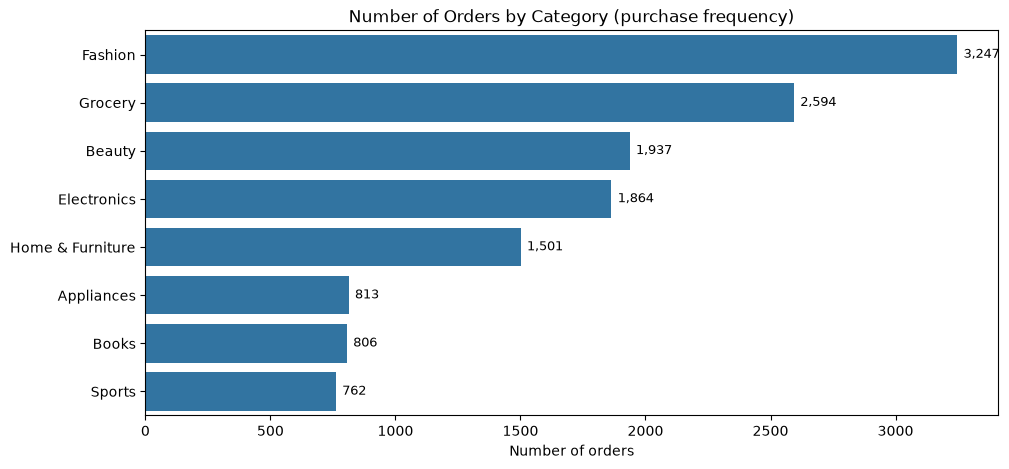

Category
Fashion             3247
Grocery             2594
Beauty              1937
Electronics         1864
Home & Furniture    1501
Appliances           813
Books                806
Sports               762
Name: count, dtype: int64


In [177]:
plt.figure(figsize=(11, 5))
order = df["Category"].value_counts().index
ax = sns.countplot(data=df, y="Category", order=order)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 25, p.get_y() + p.get_height()/2),
                va="center", fontsize=9)
plt.title("Number of Orders by Category (purchase frequency)")
plt.xlabel("Number of orders"); plt.ylabel("")
plt.show()

print(df["Category"].value_counts())

Fashion is the most frequently purchased category with 3,246 orders, followed by Grocery with 2,594 orders. Beauty and Electronics also have relatively high purchase frequency, with 1,937 and 1,864 orders, respectively.
An important insight comes from comparing this with your previous category-wise sales analysis: Fashion has the highest order frequency, but Electronics generates the highest sales revenue (54.86M). This suggests that Electronics has a much higher average transaction/order value, whereas Fashion is purchased more frequently but at comparatively lower values

In [178]:
NAVY  = "#0B1B34"     # primary
GOLD  = "#C9A227"     # accent
TEAL  = "#12807E"
RED   = "#B3261E"
GREY  = "#6B7280"

In [179]:
# Q State wise total sales 

In [180]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type'],
      dtype='str')

In [181]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

State
Maharashtra     24,880,575.46
Karnataka       12,898,767.22
Delhi           11,701,086.98
Tamil Nadu      10,303,389.32
Gujarat          9,114,914.22
Telangana        7,816,247.28
Haryana          5,362,441.64
Uttar Pradesh    4,977,078.82
Kerala           4,913,471.29
West Bengal      4,452,662.16
Name: Sales, dtype: float64

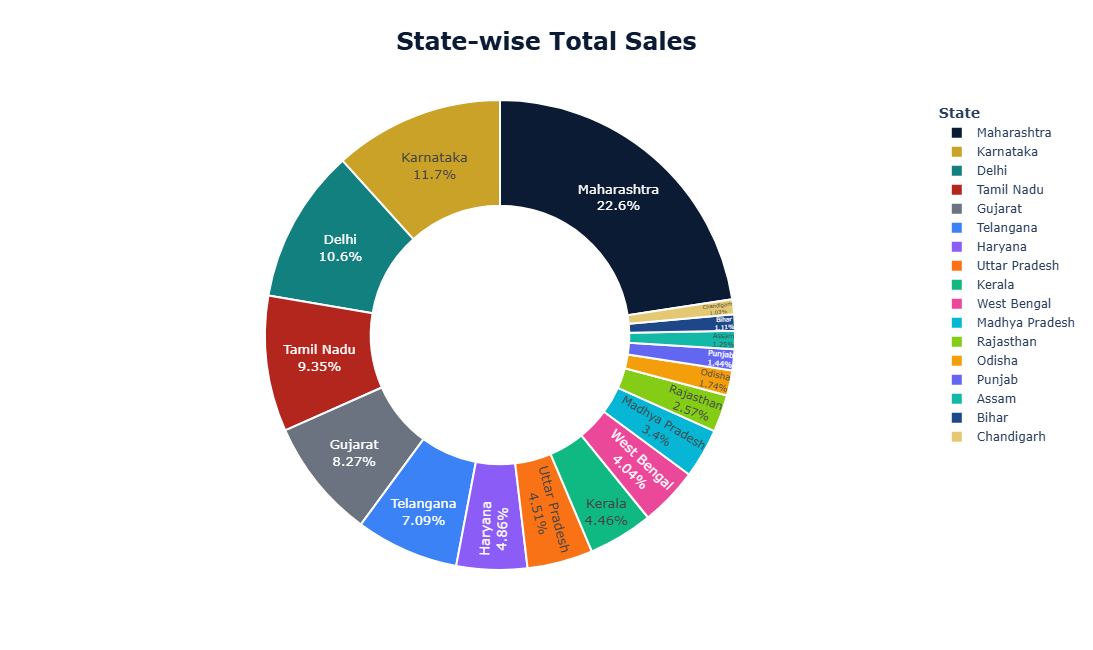

In [182]:
import plotly.express as px

# -------------------------------
# 1. State-wise Total Sales
# -------------------------------

state_sales = (
    df.groupby('State', as_index=False)['Sales']
      .sum()
      .sort_values('Sales', ascending=False)
)

# Sales in Millions
state_sales['Sales_Million'] = state_sales['Sales'] / 1_000_000


# -------------------------------
# 2. Custom Color Palette
# -------------------------------

NAVY = "#0B1B34"
GOLD = "#C9A227"
TEAL = "#12807E"
RED  = "#B3261E"
GREY = "#6B7280"

# Additional colors for other states
colors = [
    NAVY,
    GOLD,
    TEAL,
    RED,
    GREY,
    "#3B82F6",   # Blue
    "#8B5CF6",   # Purple
    "#F97316",   # Orange
    "#10B981",   # Green
    "#EC4899",   # Pink
    "#06B6D4",   # Cyan
    "#84CC16",   # Lime
    "#F59E0B",   # Amber
    "#6366F1",   # Indigo
    "#14B8A6"    # Light Teal
]


# -------------------------------
# 3. Plotly Donut Chart
# -------------------------------

fig = px.pie(
    state_sales,
    names='State',
    values='Sales_Million',
    hole=0.55,
    color_discrete_sequence=colors,
    title='State-wise Total Sales'
)


# -------------------------------
# 4. Formatting
# -------------------------------

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',

    hovertemplate=
        '<b>%{label}</b><br>' +
        'Sales: %{value:.2f}M<br>' +
        'Share: %{percent}<extra></extra>',

    marker=dict(
        line=dict(
            color='white',
            width=2
        )
    )
)


fig.update_layout(

    title=dict(
        text='<b>State-wise Total Sales</b>',
        x=0.5,
        xanchor='center',
        font=dict(
            size=24,
            color=NAVY
        )
    ),

    legend=dict(
        title='<b>State</b>',
        font=dict(size=12)
    ),

    font=dict(
        size=13
    ),

    width=1000,
    height=650
)

fig.show()

In [183]:
%pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


Maharashtra is the highest-performing state with approximately 24.88M in total sales, making it the strongest market in the dataset. Karnataka and Delhi follow as the next major contributors, while Tamil Nadu also shows strong sales performance.
Sales decline considerably for states such as Uttar Pradesh, Kerala, and West Bengal compared with the leading states. This indicates that revenue is concentrated in a few high-performing states.
Business Insight: The company should maintain strong customer engagement and product availability in Maharashtra and other leading states, while using targeted promotions, localized marketing, and improved distribution strategies to increase sales in lower-performing states.

In [184]:
df['Payment_Method'].value_counts()

Payment_Method
Upi                 5372
Credit Card         2423
Debit Card          1744
Cash On Delivery    1476
Emi                  865
Net Banking          865
Wallet               779
Name: count, dtype: int64

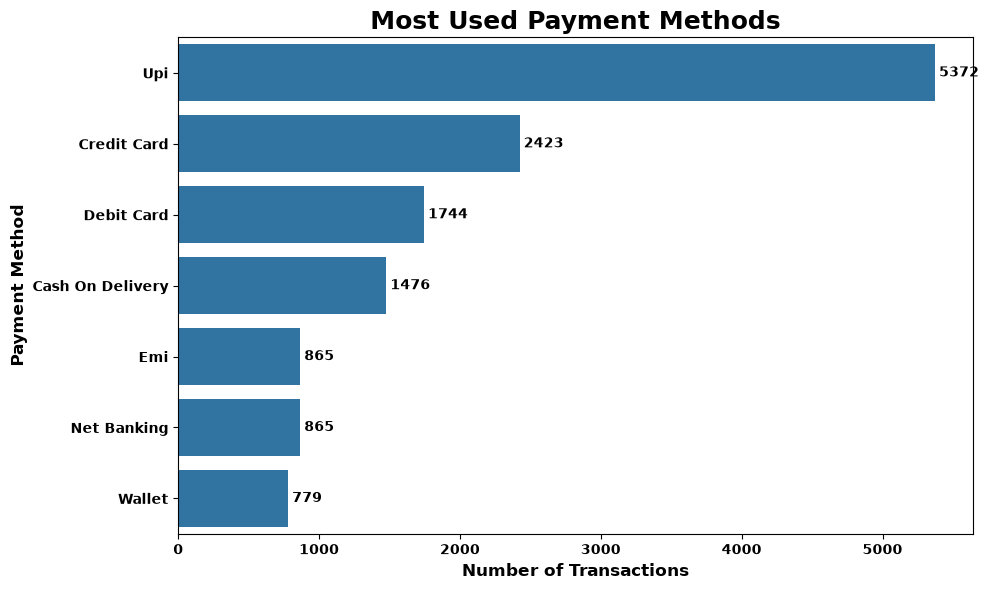

In [185]:
# Payment method counts
payment_counts = df['Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Payment_Method', 'Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=payment_counts,
    x='Count',
    y='Payment_Method'
)

# Title and labels
plt.title(
    'Most Used Payment Methods',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Number of Transactions', fontsize=12, fontweight='bold')
plt.ylabel('Payment Method', fontsize=12, fontweight='bold')

# Bold tick labels
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

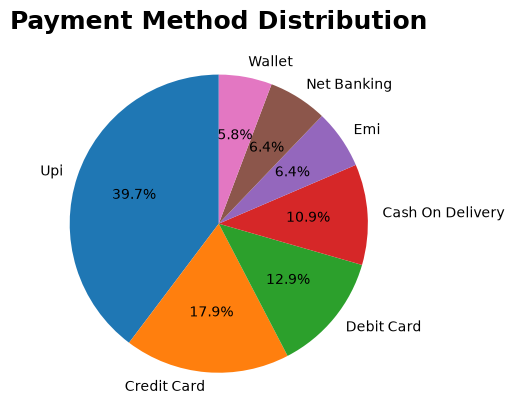

In [186]:
# Payment method counts
payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Payment Method Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Conclusion – Payment Method Distribution (%)
UPI – 39.7% → Most preferred payment method.
Credit Card – 17.9% → Second most popular.
Debit Card – 12.9%
Cash on Delivery – 10.9%
Net Banking – 6.4%
EMI – 6.4%
Wallet – 5.8% → Least used payment method.
Business Insight: UPI alone accounts for nearly 40% of all transactions, showing a strong customer preference for fast and convenient digital payments.

In [187]:
# order_status

In [188]:
df['Order_Status'].value_counts()

Order_Status
Delivered    11610
Returned       771
Shipped        687
Cancelled      456
Name: count, dtype: int64

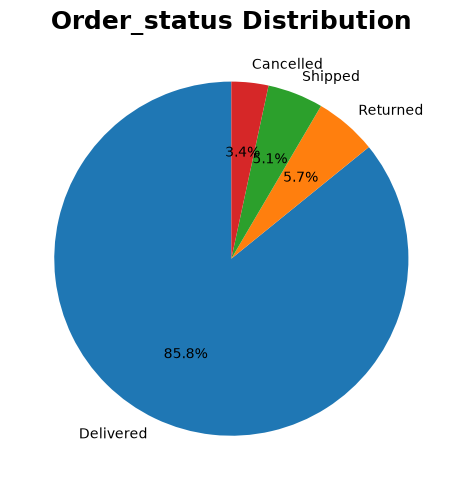

In [189]:
order_status = df['Order_Status'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    order_status.values,
    labels=order_status.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Order_status Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

The chart shows that the majority of orders (85.8%) were successfully delivered, indicating a strong overall fulfillment rate.
Delivered: 85.8% — dominant order status.
Returned: 5.7% — a relatively small but important portion of orders.
Shipped: 5.1% — orders currently in transit.
Cancelled: 3.4% — the smallest share.
Key Insight: With 85.8% delivered orders, the business demonstrates good delivery performance. However, the 5.7% return rate should be investigated to identify causes such as product quality, incorrect orders, or customer dissatisfaction.

In [190]:
# Top 10 products by revenue

In [191]:
prod = (df.groupby(["Product_Name", "Category"])
          .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"),
               Orders=("Order_ID", "count"), Units=("Quantity", "sum"))
          .reset_index())
prod["Margin_%"] = (prod["Profit"] / prod["Revenue"] * 100).round(1)
top10 = prod.sort_values("Revenue", ascending=False).head(10)

In [192]:
prod

,Product_Name,Category,Revenue,Profit,Orders,Units,Margin_%
0,Aashirvaad Atta 10Kg,Grocery,"440,770.22","8,941.62",308,964,2.00
1,Adidas Track Pants,Sports,"411,609.69","69,430.67",126,180,16.90
2,Allen Solly Formal Shirt,Fashion,"815,807.32","181,219.05",308,536,22.20
3,Amar Chitra Katha Box Set,Books,"311,259.90","62,837.46",120,333,20.20
4,Apple Watch Se,Electronics,"7,168,602.66","-147,388.41",186,227,-2.10
...,...,...,...,...,...,...,...
62,Us Polo Assn Polo T-Shirt,Fashion,"629,064.62","129,390.45",279,624,20.60
63,Voltas 1.5T Split Ac,Appliances,"3,821,564.98","188,149.32",98,115,4.90
64,W Printed Palazzo Set,Fashion,"871,514.19","195,213.63",267,587,22.40
65,Whirlpool 7Kg Top Load,Appliances,"2,287,317.13","200,483.36",102,124,8.80


In [193]:
top10

,Product_Name,Category,Revenue,Profit,Orders,Units,Margin_%
26,Hp Pavilion 15,Electronics,"14,002,179.05","-200,259.64",183,237,-1.40
34,Lenovo Ideapad Slim 3,Electronics,"9,958,010.69","-107,153.25",185,241,-1.10
13,Canon Eos 1500D,Electronics,"7,780,106.66","424,248.12",173,213,5.50
4,Apple Watch Se,Electronics,"7,168,602.66","-147,388.41",186,227,-2.10
48,Oneplus Nord Ce4,Electronics,"5,457,678.07","-10,980.06",189,323,-0.20
54,Samsung Galaxy M35,Electronics,"4,849,666.26","90,240.94",210,256,1.90
63,Voltas 1.5T Split Ac,Appliances,"3,821,564.98","188,149.32",98,115,4.90
52,Redmi Note 13 5G,Electronics,"3,738,957.44","61,141.46",191,237,1.60
28,Ifb 6.5Kg Front Load,Appliances,"3,674,139.25","112,679.16",102,118,3.10
36,Lg 260L Double Door Fridge,Appliances,"3,449,637.27","235,655.52",108,122,6.80


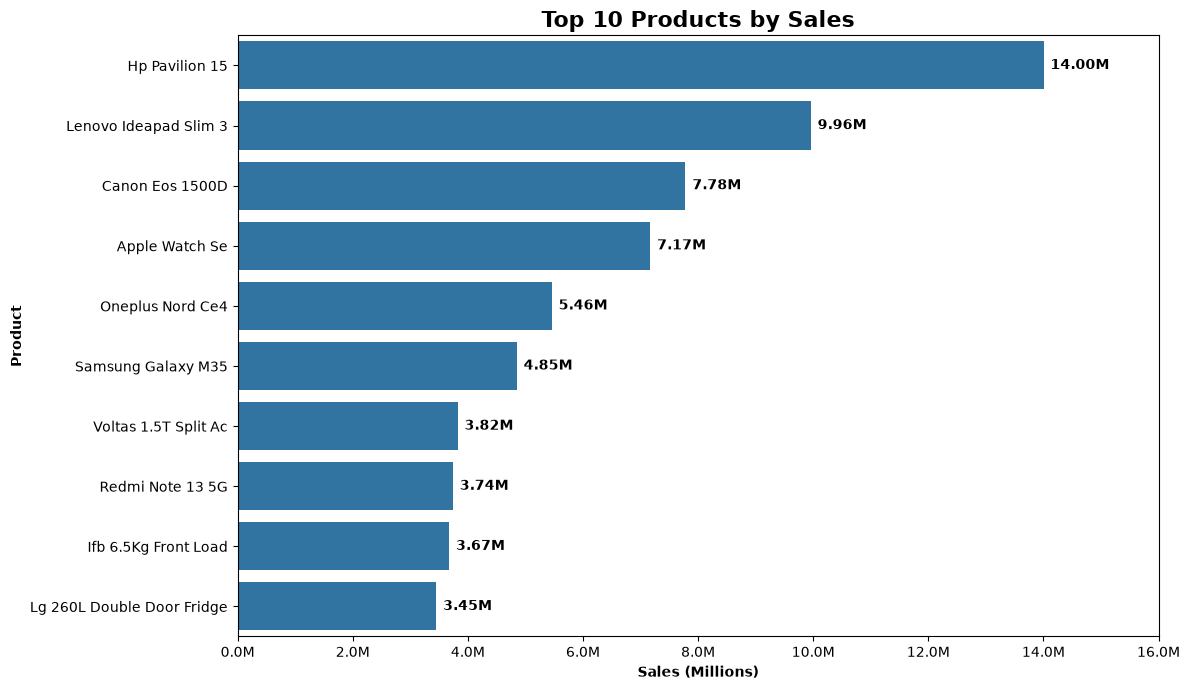

In [194]:
# Sort Top 10 for horizontal bar chart
plot_data = top10.sort_values("Revenue", ascending=False)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=plot_data,
    x="Revenue",
    y="Product_Name"
)

# Add sales labels in Millions
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in container.datavalues],
        padding=5,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Top 10 Products by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales (Millions)", fontweight="bold")
plt.ylabel("Product", fontweight="bold")

plt.xticks(
    ticks=ax.get_xticks(),
    labels=[f'{x/1_000_000:.1f}M' for x in ax.get_xticks()]
)

plt.tight_layout()
plt.show()

HP Pavilion 15 is the highest-selling product with approximately 14.0M in sales, followed by Lenovo IdeaPad Slim 3 (9.96M) and Canon EOS 1500D (7.78M).
However, high sales do not always mean high profitability. HP Pavilion 15 generates the highest revenue but records approximately 200K negative profit with a −1.4% profit margin, whereas Canon EOS 1500D maintains a positive 5.5% margin.
Key Insight: Electronics dominate the Top 10 products by sales. The business should focus on both sales growth and profitability, especially improving margins on high-revenue products.

In [195]:
top10 = prod.sort_values("Profit", ascending=False).head(10)

In [196]:
top10

,Product_Name,Category,Revenue,Profit,Orders,Units,Margin_%
57,Sleepwell Foam Mattress,Home & Furniture,"3,362,429.09","525,151.49",230,300,15.60
13,Canon Eos 1500D,Electronics,"7,780,106.66","424,248.12",173,213,5.50
25,Hidesign Leather Handbag,Fashion,"2,220,294.25","356,798.57",272,489,16.10
23,Godrej Interio Bookshelf,Home & Furniture,"2,461,752.05","310,717.16",214,283,12.60
61,Titan Neo Analog Watch,Fashion,"1,608,128.74","296,351.19",247,423,18.40
19,Fabindia Cotton Saree,Fashion,"1,617,679.52","285,833.02",282,514,17.70
36,Lg 260L Double Door Fridge,Appliances,"3,449,637.27","235,655.52",108,122,6.80
47,Nykaa Eau De Parfum,Beauty,"669,587.87","223,257.30",268,729,33.30
35,Levi'S Slim Fit Jeans,Fashion,"1,035,561.97","216,664.07",261,610,20.90
8,Biba Anarkali Kurta,Fashion,"814,452.05","213,503.99",247,420,26.20


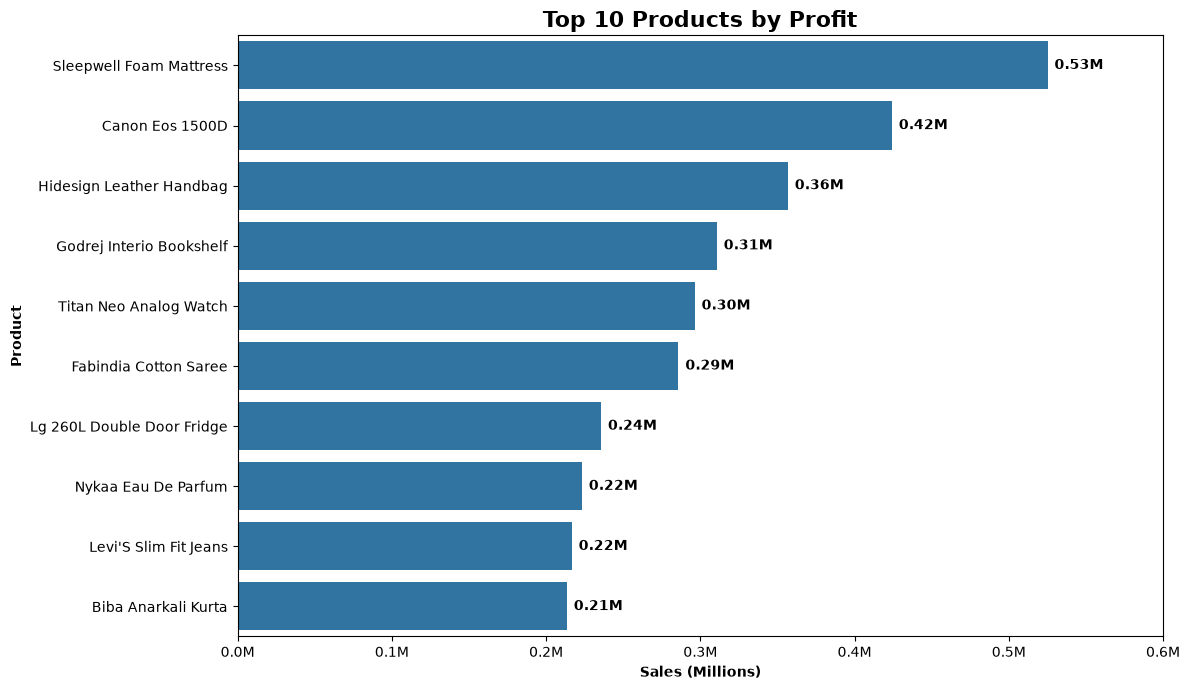

In [197]:
# Sort Top 10 for horizontal bar chart
plot_data = top10.sort_values("Profit", ascending=False)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=plot_data,
    x="Profit",
    y="Product_Name"
)

# Add sales labels in Millions
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in container.datavalues],
        padding=5,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Top 10 Products by Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales (Millions)", fontweight="bold")
plt.ylabel("Product", fontweight="bold")

plt.xticks(
    ticks=ax.get_xticks(),
    labels=[f'{x/1_000_000:.1f}M' for x in ax.get_xticks()]
)

plt.tight_layout()
plt.show()

In [198]:
# year wise anlalysis

In [199]:
df['Year']=df['Order_Date'].dt.year

In [200]:
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type,Year
0,Ord101152,2024-03-21,Cust13416,Tanvi Rao,Female,23,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1Kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,Upi,Delivered,5,4.20,Premium,Mobile App,2024
1,Ord107594,2025-01-31,Cust12988,Swapnil Chatterjee,Female,44,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window Ac,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App,2025
2,Ord102186,2024-05-21,Cust12825,Swapnil Bhat,Male,32,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet,2024
3,Ord113618,2025-11-08,Cust12560,Imran Sharma,Female,42,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women'S Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash On Delivery,Returned,5,2.90,Regular,Mobile App,2025
4,Ord109118,2025-05-01,Cust11485,Deepak Mishra,Female,18,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10Kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash On Delivery,Cancelled,8,3.20,Premium,Desktop,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,Ord105700,2024-11-02,Cust13071,Kabir Sharma,Male,28,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App,2024
13536,Ord110743,2025-07-24,Cust12928,Kavya Das,Male,32,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App,2025
13537,Ord100538,2024-02-08,Cust11722,Priya Rao,Female,25,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web,2024
13538,Ord109413,2025-05-16,Cust13273,Amit Mishra,Male,40,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,Emi,Delivered,3,4.40,Budget,Mobile App,2025


In [201]:
year_sales=pd.pivot_table(data=df,values='Sales',index='Year')

In [202]:
year_sales

,Sales
Year,
2024,"8,318.82"
2025,"8,002.63"


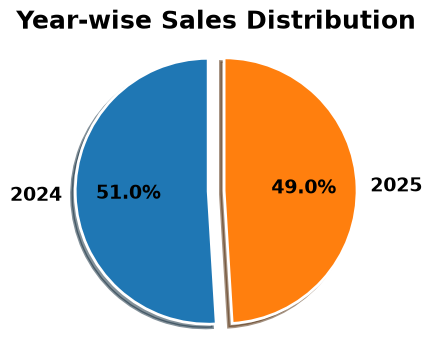

In [203]:
plt.figure(figsize=(4, 4))

plt.pie(
    year_sales['Sales'],
    labels=year_sales.index,
    autopct='%1.1f%%',
    explode=[0.06] * len(year_sales),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title(
    'Year-wise Sales Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.axis('equal')
plt.show()

2024 contributes approximately 51.% of total sales, compared with 49.% in 2025. Sales declined slightly in 2025, indicating that overall performance remained relatively stable but experienced a small year-on-year decrease.

In [204]:
# device type 

In [205]:
df['Device_Type'].value_counts()

Device_Type
Mobile App    7863
Desktop       2704
Mobile Web    2316
Tablet         641
Name: count, dtype: int64

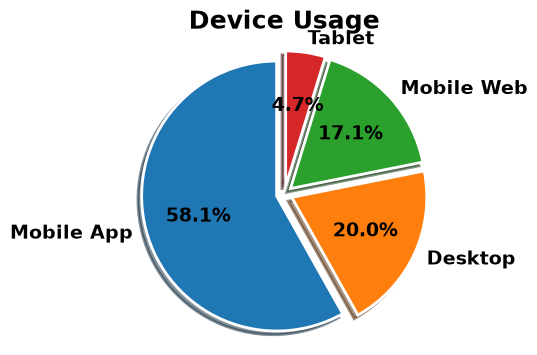

In [206]:
plt.figure(figsize=(4, 4))
s1=df['Device_Type'].value_counts()
plt.pie(
    s1.values,
    labels=s1.index,
    autopct='%1.1f%%',
    explode=[0.06] * len(s1),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title(
    'Device Usage',
    fontsize=18,
    fontweight='bold'
)

plt.axis('equal')
plt.show()

Mobile App is the dominant device type, accounting for approximately 58.1% of records. Desktop contributes around 20.0%, followed by Mobile Web at 17.1%, while Tablet has the smallest share at approximately 4.7%.
Key Insight: Most customers interact through the Mobile App, indicating that the business should prioritize mobile-app performance, usability, and customer experience.

In [207]:
# location

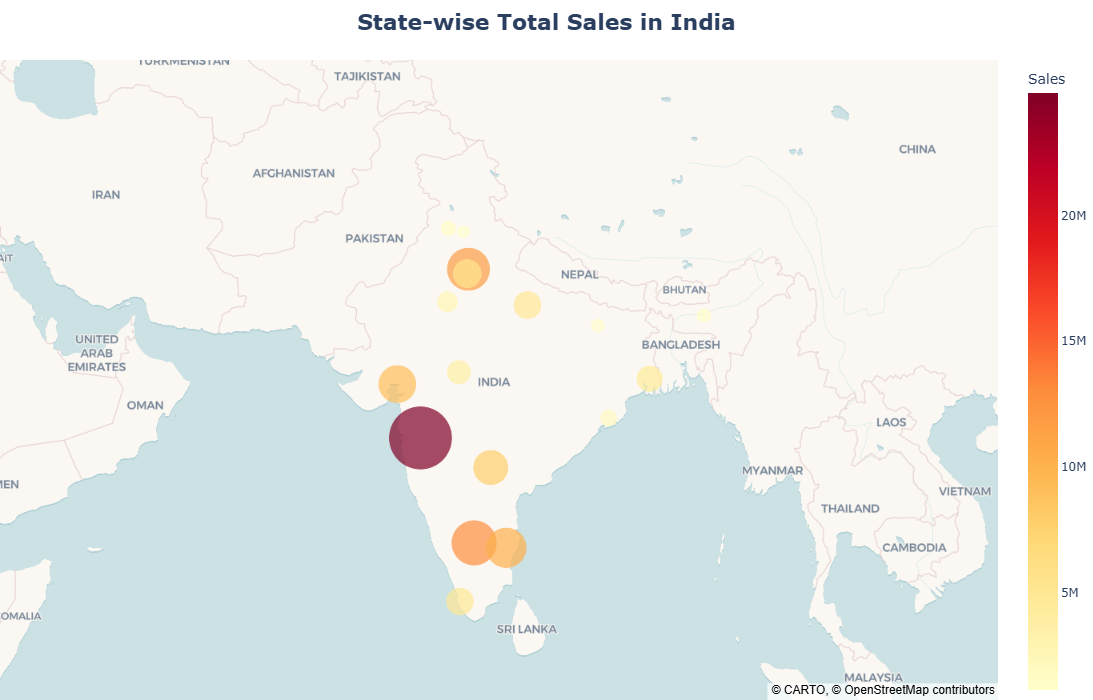

In [208]:
import plotly.express as px

# State-wise total sales
state_sales = df.groupby('State', as_index=False).agg({
    'Sales': 'sum',
    'Latitude': 'mean',
    'Longitude': 'mean'
})

# Create map
fig = px.scatter_map(
    state_sales,
    lat='Latitude',
    lon='Longitude',
    size='Sales',
    color='Sales',
    hover_name='State',
    hover_data={'Sales': ':,.0f'},
    size_max=45,
    zoom=3.5,
    center={'lat': 22.5, 'lon': 79},
    color_continuous_scale='YlOrRd',
    title='<b>State-wise Total Sales in India</b>'
)

fig.update_layout(
    height=700,
    title_x=0.5,
    title_font_size=22,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()

In [209]:
# rating

In [210]:
# top 10 product by rating

In [211]:
rating=pd.pivot_table(data=df,values='Customer_Rating',index='Product_Name',aggfunc='mean')

In [212]:
rating.nlargest(10,'Customer_Rating')

,Customer_Rating
Product_Name,
Aashirvaad Atta 10Kg,4.46
India Gate Basmati Rice 5Kg,4.44
Kore Dumbbell Set 20Kg,4.44
Mamaearth Onion Shampoo,4.43
Lg 260L Double Door Fridge,4.43
Ncert Class 12 Bundle,4.42
Bru Instant Coffee 200G,4.41
Atomic Habits,4.41
Minimalist Vitamin C Serum,4.41


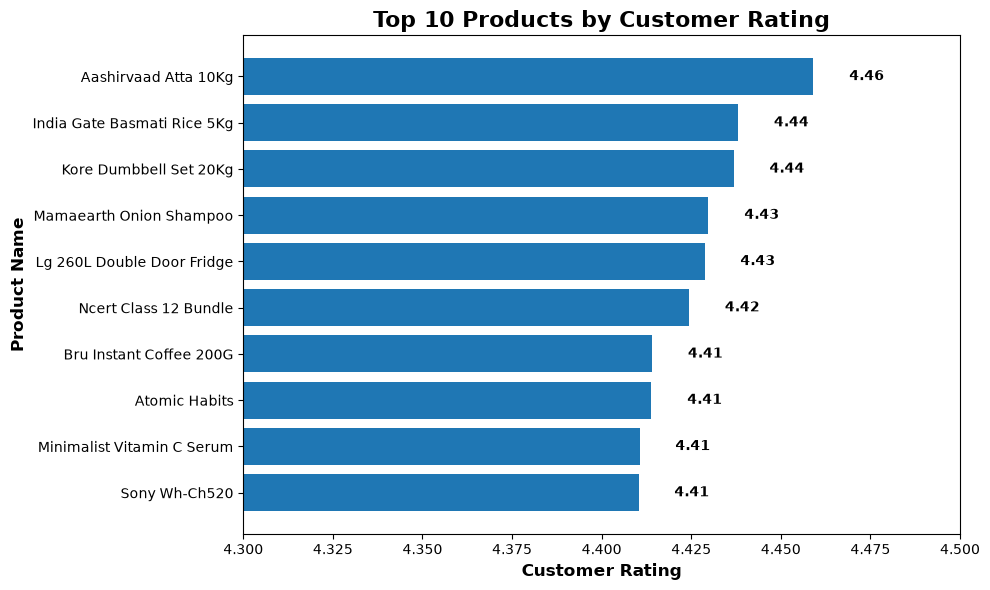

In [213]:
top_rating = rating.nlargest(10, 'Customer_Rating')

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_rating.index,
    top_rating['Customer_Rating']
)

# Show rating on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center',
        fontweight='bold'
    )

plt.xlabel('Customer Rating', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

plt.title(
    'Top 10 Products by Customer Rating',
    fontsize=16,
    fontweight='bold'
)

# Zoom into relevant rating range
plt.xlim(4.3, 4.5)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Aashirvaad Atta 10Kg has the highest customer rating at 4.46, making it the best-rated product among the Top 10.
India Gate Basmati Rice 5Kg and Kore Dumbbell Set 20Kg jointly rank next with ratings of 4.44, followed by Mamaearth Onion Shampoo and LG 260L Double Door Fridge at 4.43.
All Top 10 products have ratings between 4.41 and 4.46, showing consistently high customer satisfaction with very little variation.
Key Insight: The narrow rating range suggests that several products are performing strongly in customer satisfaction; the business can study the highest-rated products to identify factors driving positive customer experiences.

In [214]:
rating.nsmallest(10,'Customer_Rating')

,Customer_Rating
Product_Name,
W Printed Palazzo Set,4.25
Wildcraft Laptop Backpack,4.25
Fastrack Casual Watch,4.27
Allen Solly Formal Shirt,4.27
Puma Running Shoes,4.29
Us Polo Assn Polo T-Shirt,4.29
Bata Formal Shoes,4.30
Nilkamal Study Table,4.30
Cockatoo Exercise Cycle,4.30


In [215]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'Year'],
      dtype='str')